In [359]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

In [360]:
df = pd.read_csv('./data/cytof.csv', index_col=0)
df['observableId'].unique()

array(['CyclinB', 'GAPDH', 'IdU', 'Ki.67', 'b.CATENIN', 'cleavedCas',
       'p.4EBP1', 'p.AKT.Thr308.', 'p.AMPK', 'p.Akt.Ser473.', 'p.BTK',
       'p.CREB', 'p.ERK', 'p.FAK', 'p.GSK3b', 'p.H3', 'p.HER2', 'p.JNK',
       'p.MAP2K3', 'p.MAPKAPK2', 'p.MEK', 'p.MKK3.MKK6', 'p.MKK4',
       'p.NFkB', 'p.PDPK1', 'p.PLCg2', 'p.RB', 'p.S6', 'p.S6K',
       'p.SMAD23', 'p.SRC', 'p.STAT1', 'p.STAT3', 'p.STAT5', 'p.p38',
       'p.p53', 'p.p90RSK'], dtype=object)

In [361]:
def nan_euclidean(u, v):
    mask = np.isfinite(u) & np.isfinite(v)
    if np.sum(mask) == 0:
        return np.nan  # Or a large constant like 1e6
    return np.mean(np.square(u[mask] - v[mask]))

In [362]:
def plot_markers(cytof_markers, pmarkers):
    df = pd.read_csv('./data/cytof.csv', index_col=0)
    df = df[df['observableId'].isin(cytof_markers)]
    cell_lines = df['preequilibrationConditionId'].unique()
    df['treatment'] = df['simulationConditionId'].str.split('__').str[1]
    dfp = df.pivot_table(index=['treatment', 'time', 'observableId'], columns='preequilibrationConditionId', values='measurement').reset_index()

    # hierarchical clustering
    distance_matrix = pdist(dfp.loc[
        (dfp.treatment=='EGF') & (dfp.isna().sum(axis=1) < 10),
        cell_lines
    ].T, metric=nan_euclidean)
    linkage_matrix = linkage(distance_matrix, method='centroid')
    d = dendrogram(linkage_matrix, labels=cell_lines, no_plot=True)
    n_treatments = dfp['treatment'].nunique()
    n_observables = dfp['observableId'].nunique()
    fig, axes = plt.subplots(figsize=(40, 15), nrows=n_observables+2, ncols=n_treatments)

    df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

    df_tx = df_tx[df_tx['observableId'].isin(pmarkers)].pivot_table(
        index='observableId',
        columns='preequilibrationConditionId',
        values='measurement'
    )

    df_px = pd.read_csv('./data/proteomics.csv', index_col=0)

    df_px = df_px[df_px['observableId'].isin(pmarkers)].pivot_table(
        index='observableId',
        columns='preequilibrationConditionId',
        values='measurement'
    )

    gb = ['observableId', 'treatment',]
    for iax, (ax, ((marker, treatment), group)) in enumerate(zip(axes.flatten(), dfp.groupby(gb))):
        df_plot = group[group.isna().sum(axis=1) < 30]  # remove rows with too many NaNs
        time = df_plot['time'].unique()
        df_plot = df_plot.drop(columns=gb+['time'])
        sns.heatmap(
            df_plot[d['ivl']], ax=ax, cmap='cubehelix', cbar=False, yticklabels=time,
        )
        ax.set_xticklabels([])
        if iax < n_treatments:
            ax.set_title(treatment)
        if iax % n_treatments == 0:
            ax.set_ylabel(marker)
        else:
            ax.set_ylabel('')
        ax.set_xlabel('')
    for ax in axes[-2,:]:
        sns.heatmap(
            df_px[d['ivl']], ax=ax, cmap='viridis', cbar=False, yticklabels=True,
        )
        ax.set_xticklabels([])
        ax.set_ylabel('proteomics')
        ax.set_xlabel('')
    for ax in axes[-1,:]:
        sns.heatmap(
            df_tx[d['ivl']], ax=ax, cmap='viridis', cbar=False, yticklabels=True,
        )
        ax.set_xticks([x+0.7 for x in range(len(d['ivl']))])
        ax.set_xticklabels(d['ivl'], rotation=90)
        ax.set_xlabel('cell lines')
        ax.set_ylabel('transcriptomics')
    plt.tight_layout()

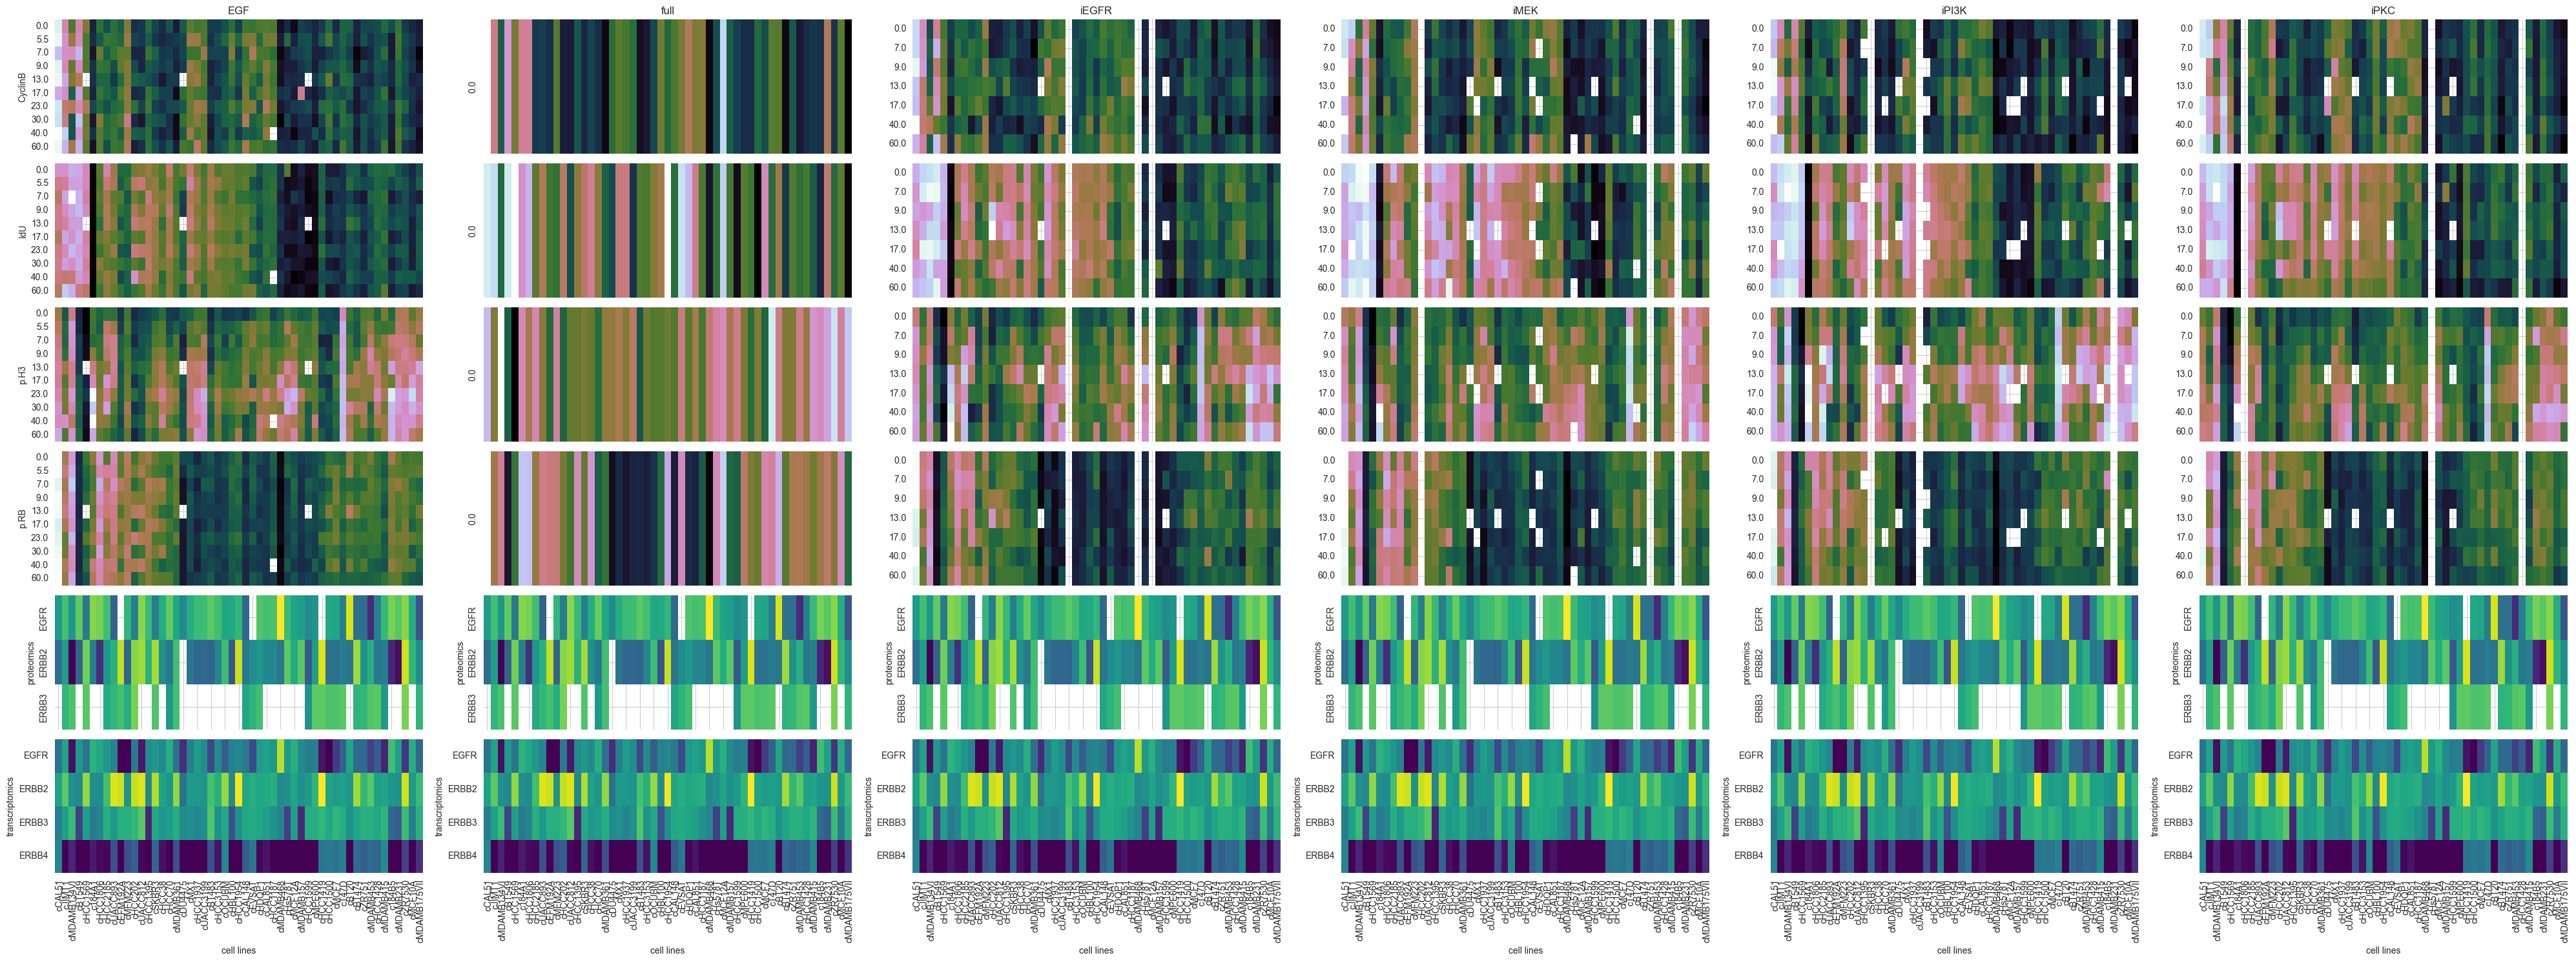

In [363]:
# cell cycle
plot_markers(['CyclinB', 'p.H3', 'p.RB', 'IdU'], ['EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

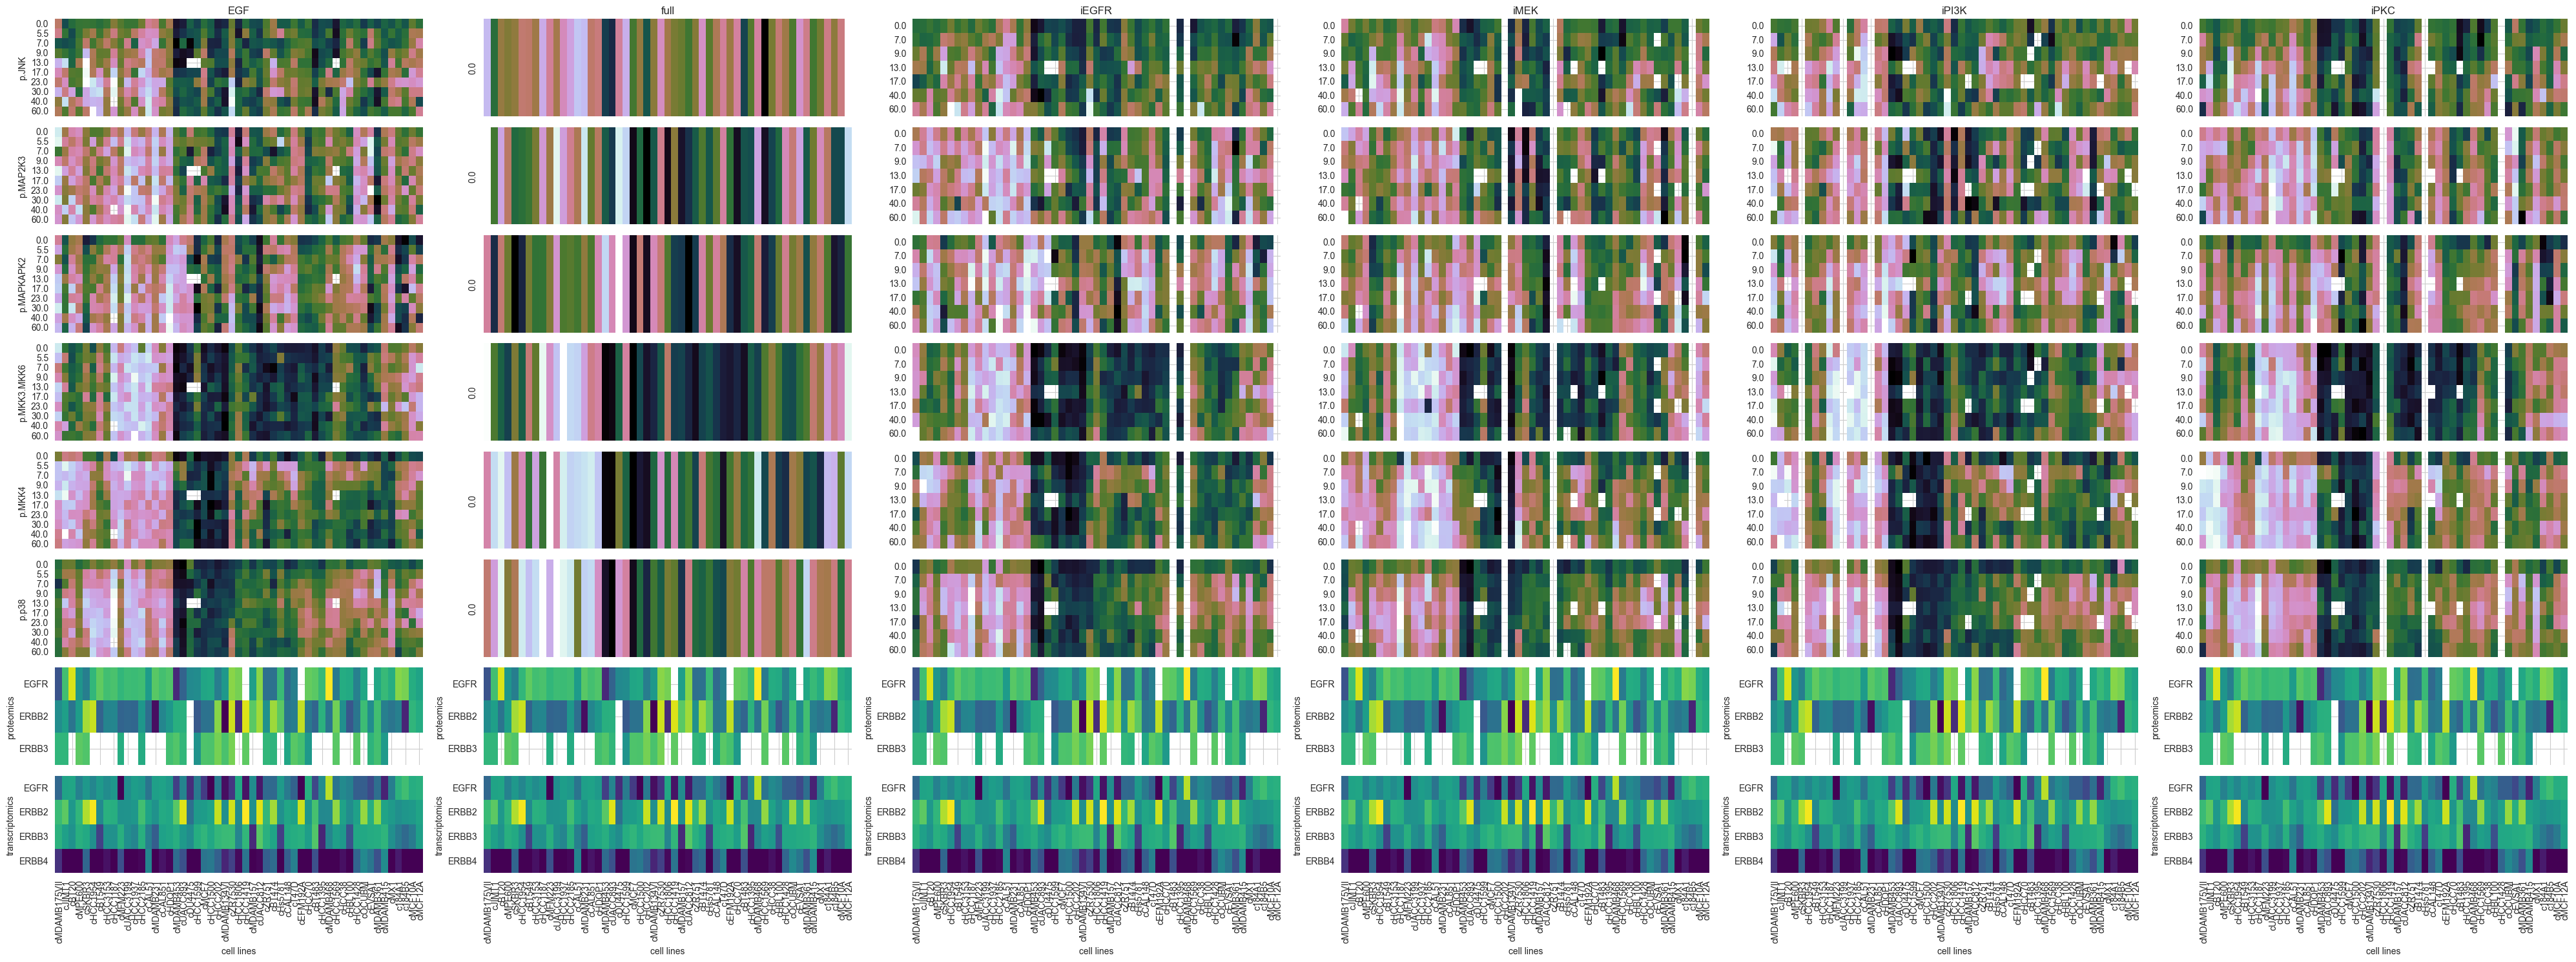

In [364]:
# p38
plot_markers(['p.MKK4', 'p.MAP2K3', 'p.MKK3.MKK6', 'p.p38', 'p.MAPKAPK2', 'p.JNK'], ['EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

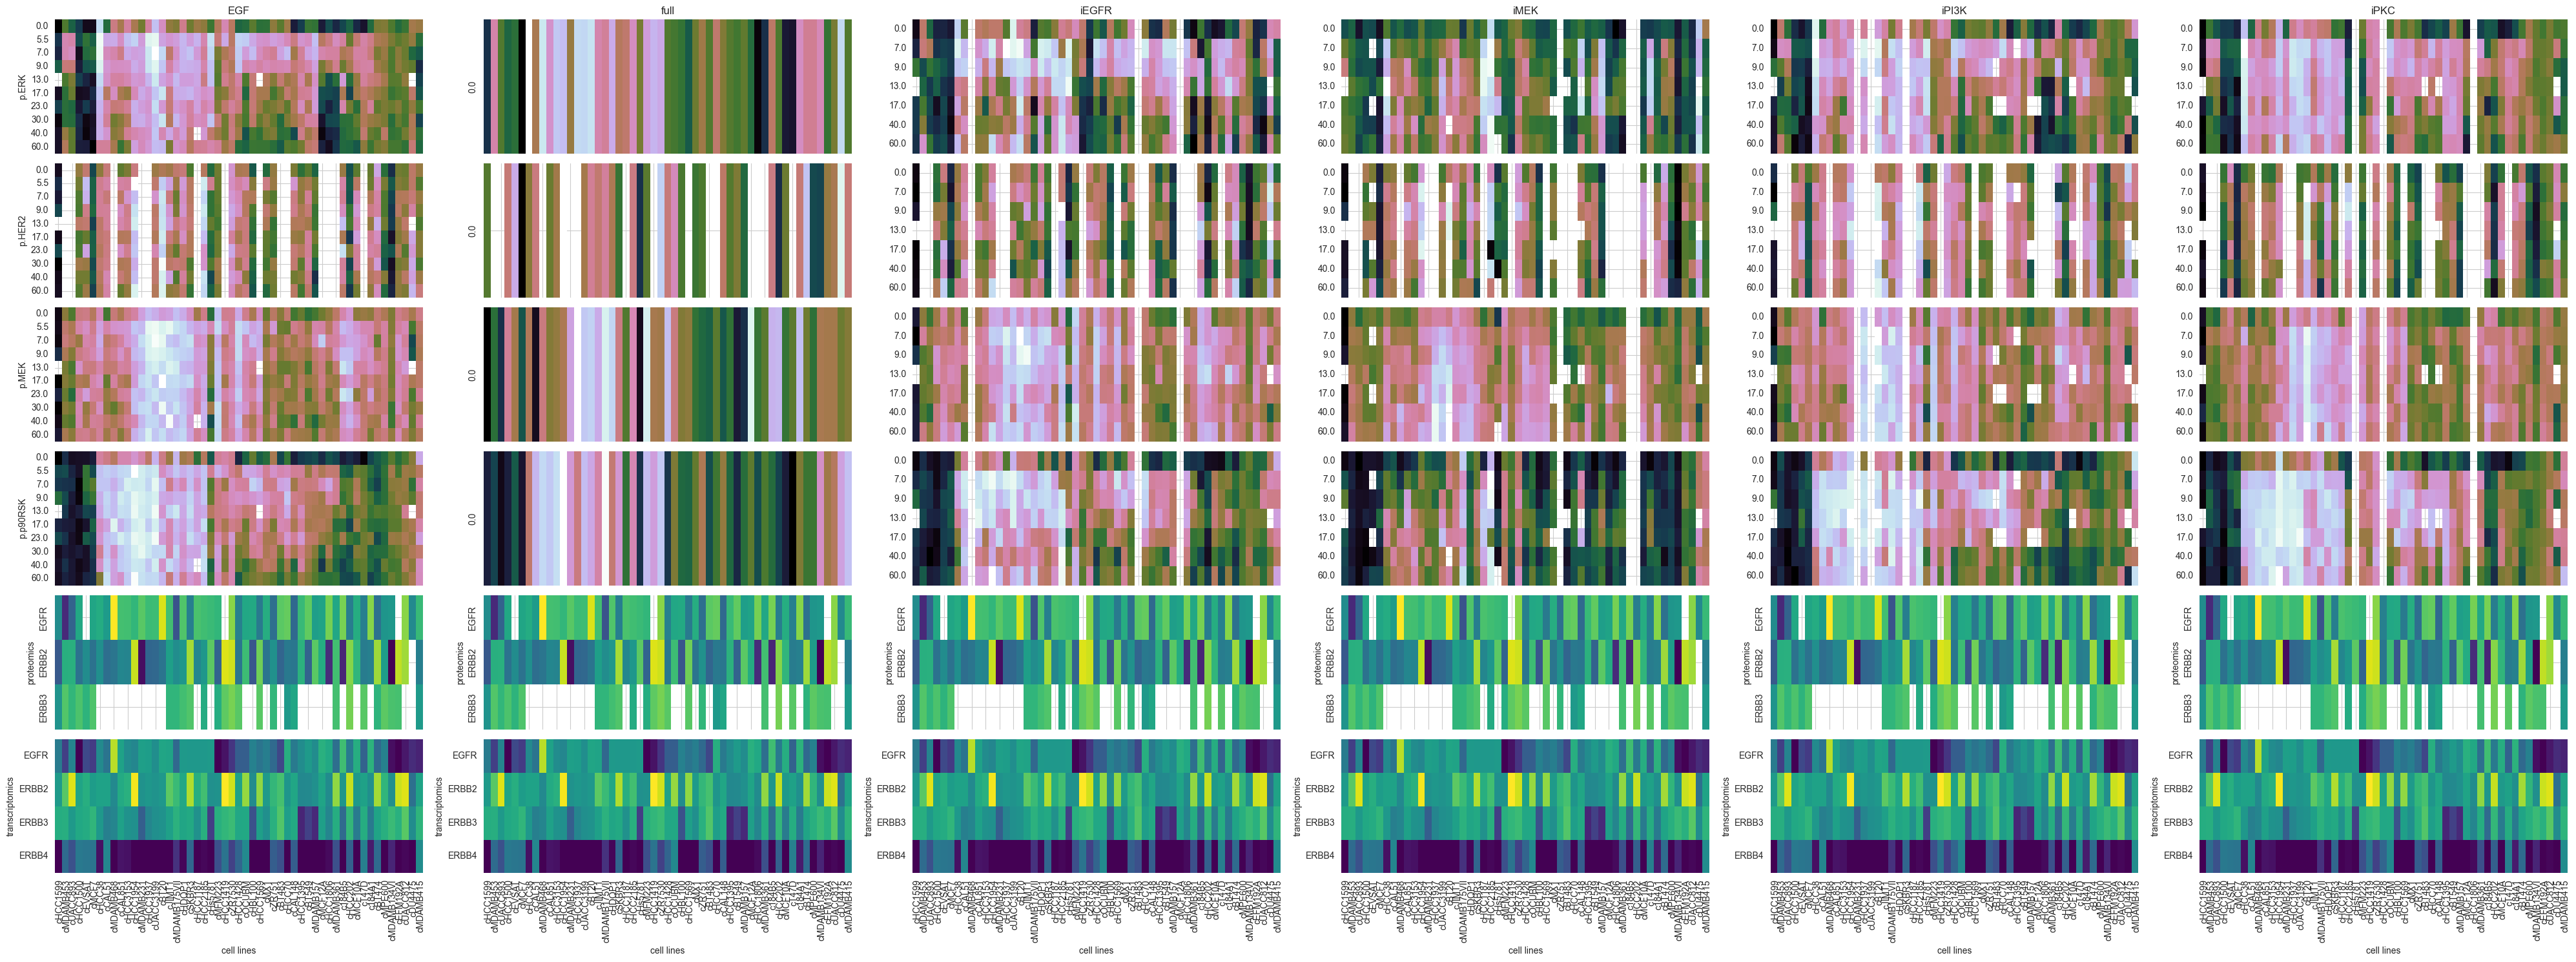

In [365]:
# mapk
plot_markers(['p.HER2','p.MEK', 'p.ERK', 'p.p90RSK'], ['EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

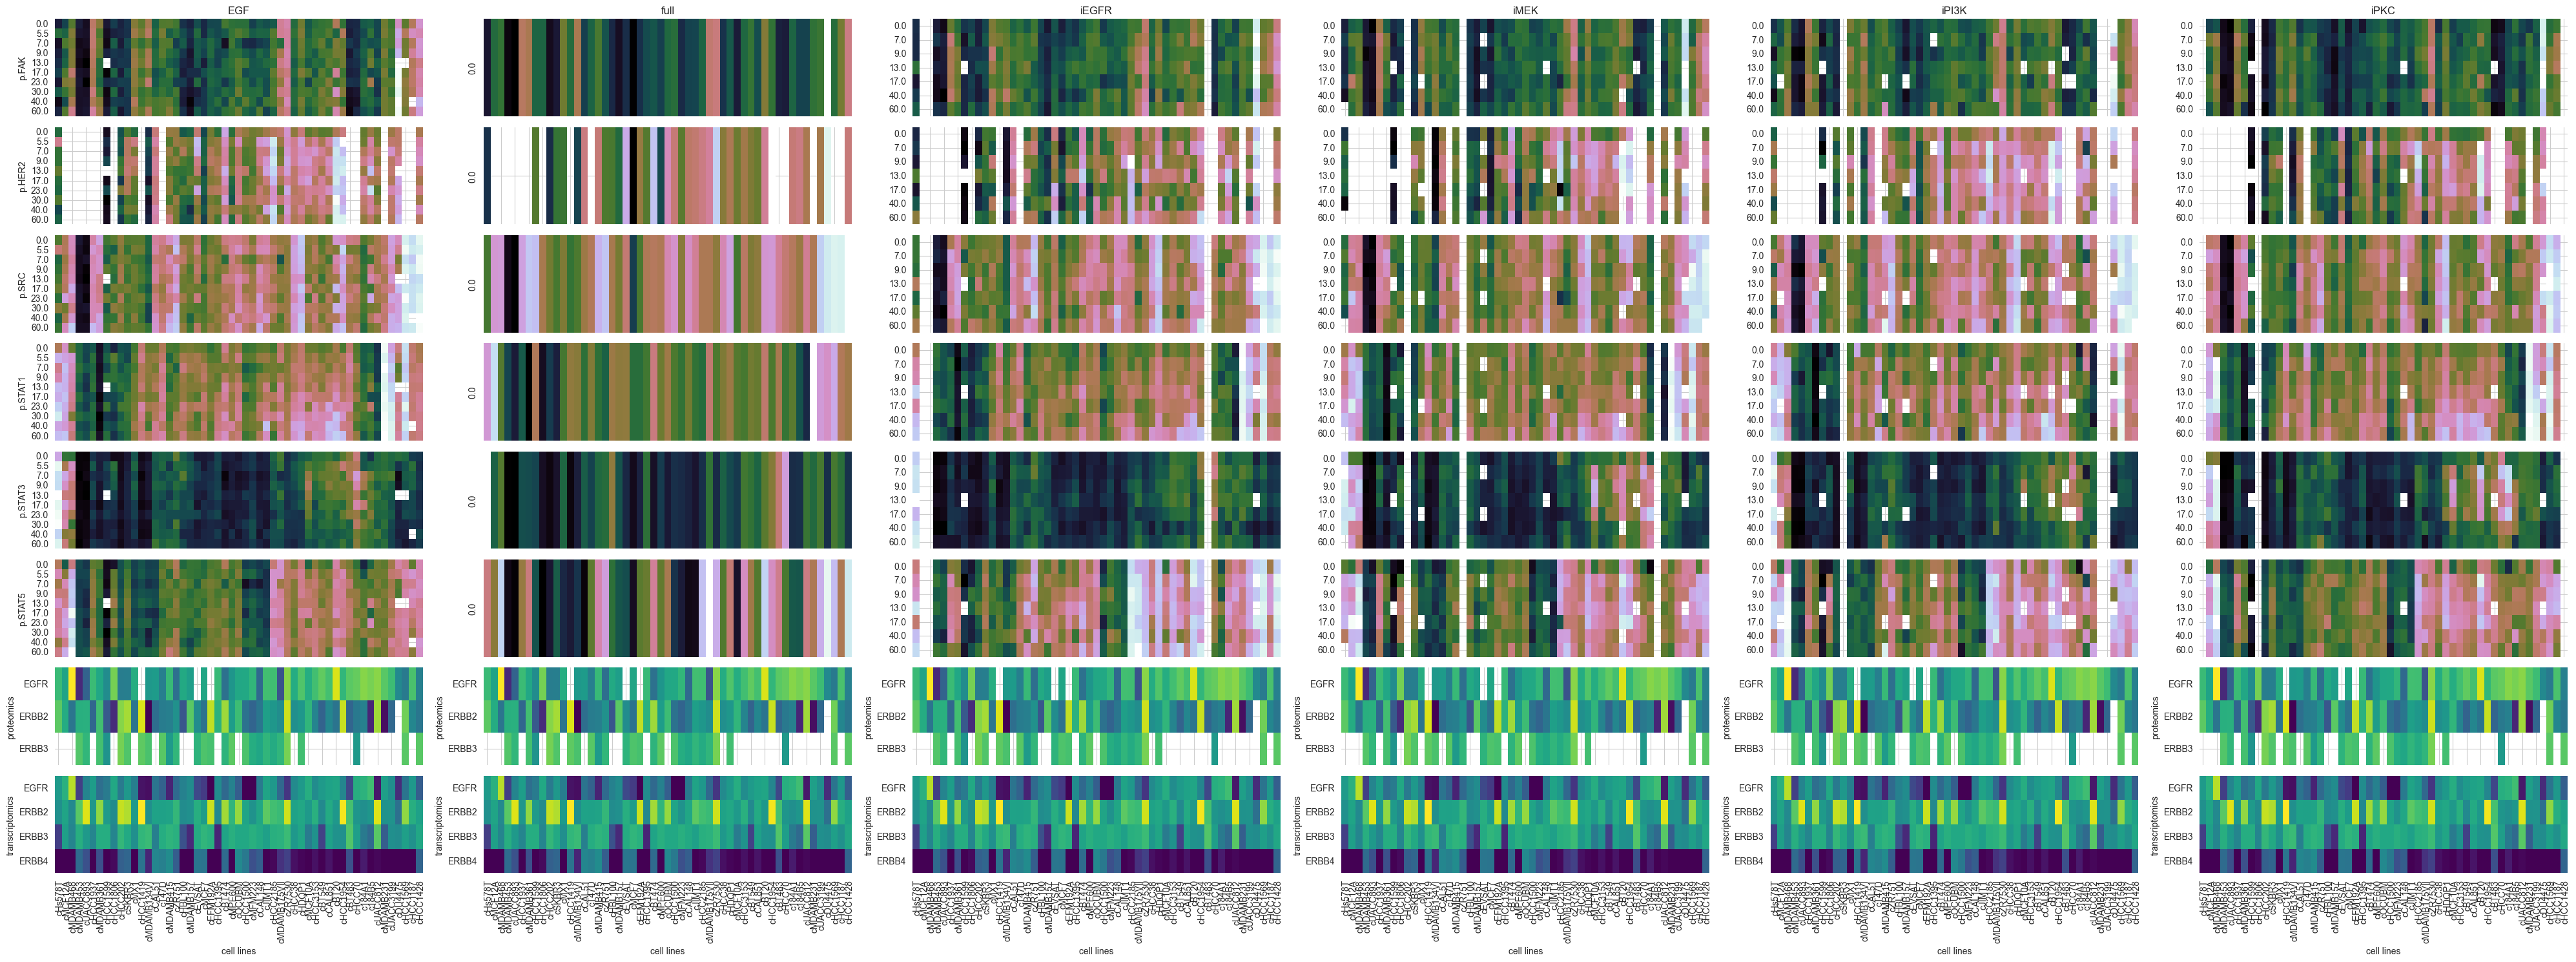

In [366]:
# ecm
plot_markers(['p.HER2','p.SRC', 'p.STAT1', 'p.STAT3', 'p.STAT5', 'p.FAK'], ['EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

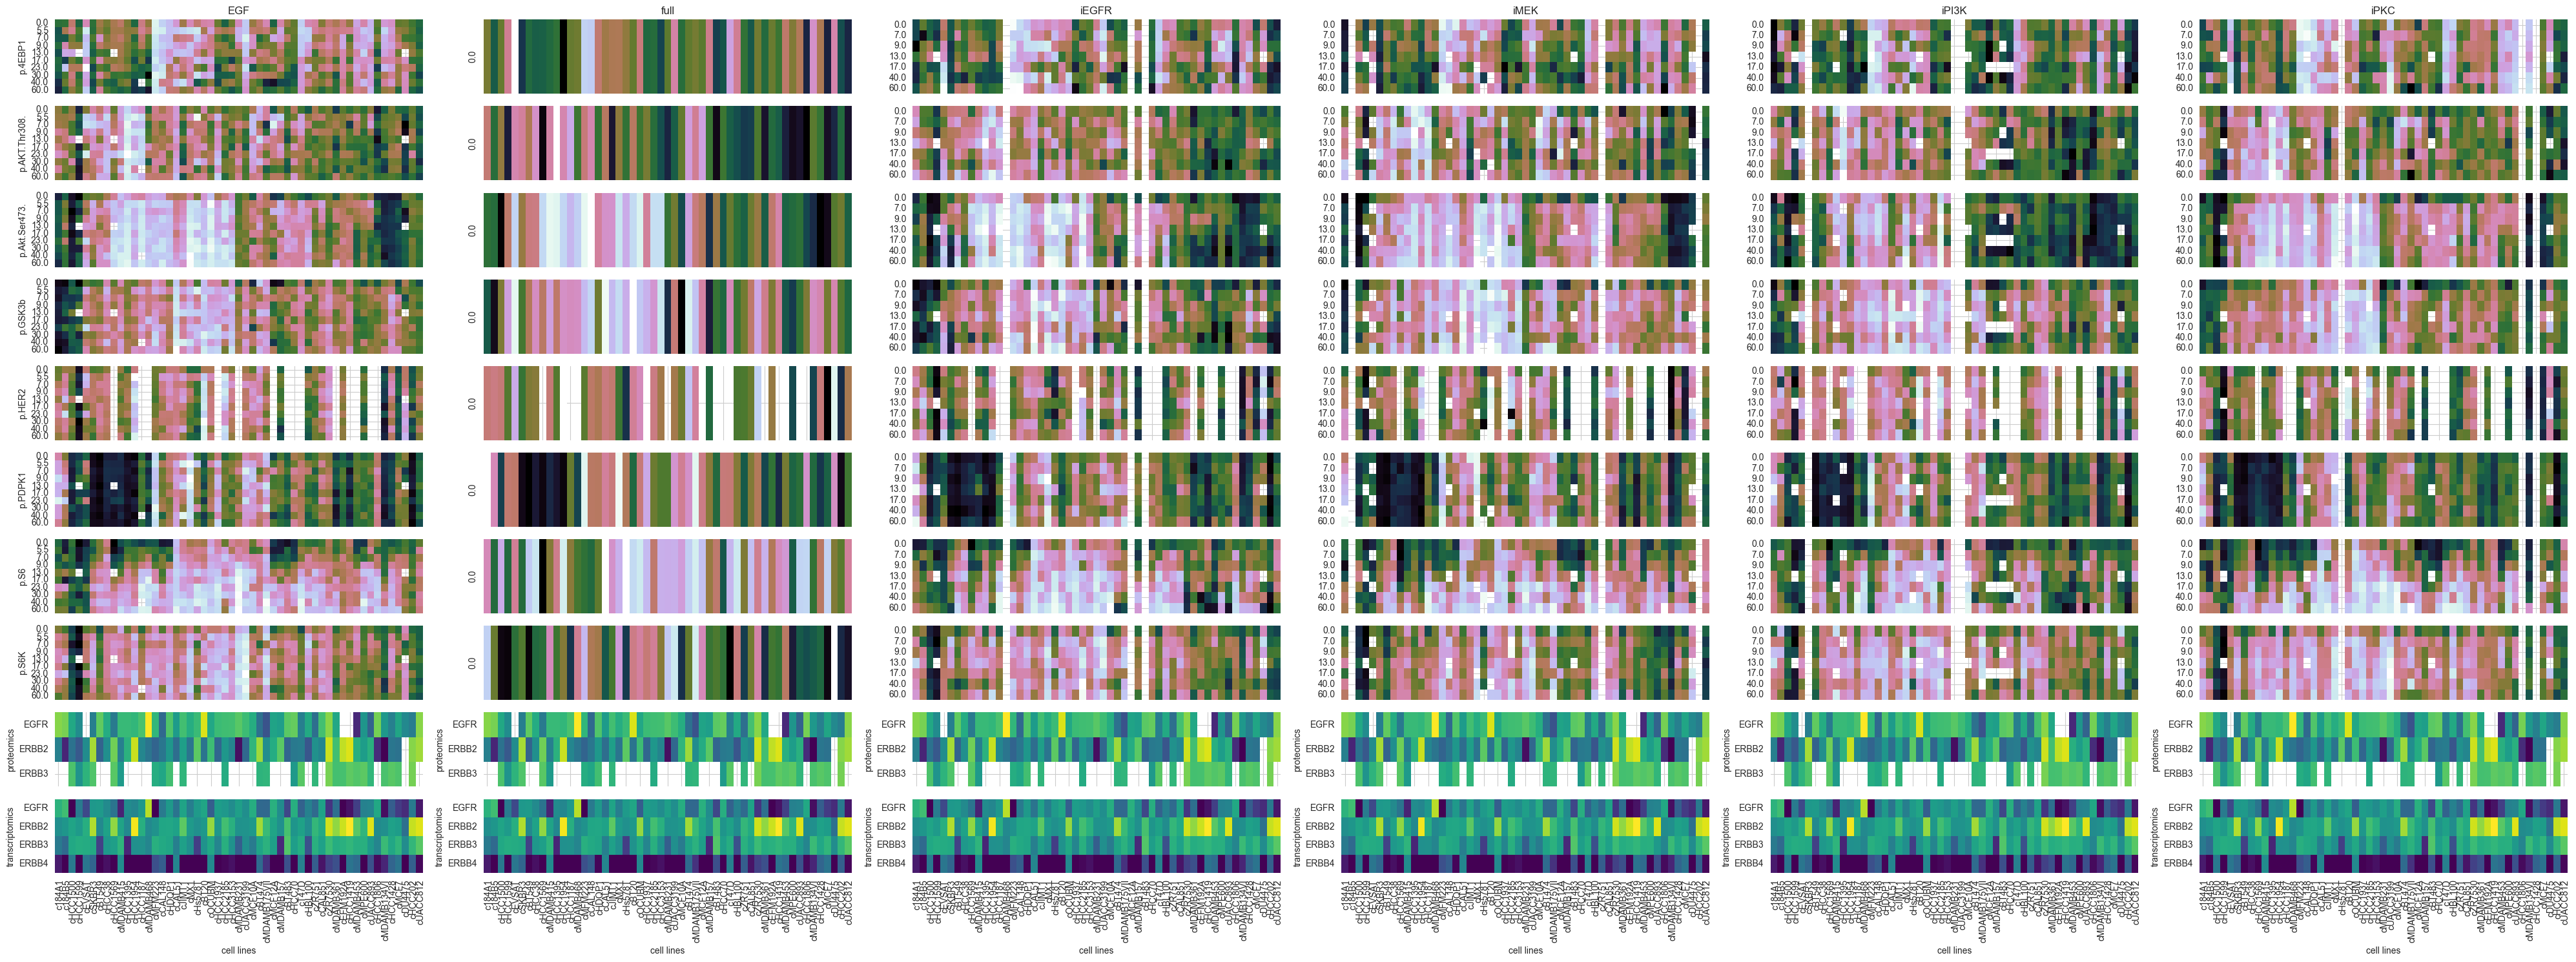

In [367]:
plot_markers(['p.HER2', 'p.4EBP1', 'p.AKT.Thr308.', 'p.Akt.Ser473.', 'p.S6', 'p.S6K', 'p.PDPK1', 'p.GSK3b'], ['EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

In [368]:
df['treatment'] = df['simulationConditionId'].str.split('__').str[1]
dfm = df[df.observableId.isin(['p.Akt.Ser473.', 'p.AKT.Thr308.', 'p.PDK1', 'p.GSK3b', 'p.p90RSK', 'p.SRC', 'p.ERK', 'p.MKK3.MKK6', 'p.MKK4', 'p.p38', 'p.JNK', 'p.HER2', 'p.PDPK1', 'p.MEK'])]
dfp = dfm[dfm.treatment=='EGF'].pivot_table(index=['time', 'observableId'], columns='preequilibrationConditionId', values='measurement').reset_index()

In [369]:
from scipy.stats import zscore
dfz = dfp.groupby('observableId').agg("median").drop(columns='time').T.apply(zscore, nan_policy='omit')
dfz

observableId,p.AKT.Thr308.,p.Akt.Ser473.,p.ERK,p.GSK3b,p.HER2,p.JNK,p.MEK,p.MKK3.MKK6,p.MKK4,p.PDPK1,p.SRC,p.p38,p.p90RSK
preequilibrationConditionId,,,,,,,,,,,,,
c184A1,0.004404,-1.468179,0.234175,-2.849387,0.128926,-0.122498,0.015283,0.333970,0.041638,1.519314,-1.039207,-0.559474,-1.005100
c184B5,-0.105700,-0.845546,-0.175649,-2.511918,0.655053,-0.324019,0.560742,0.555045,0.359963,0.720388,-0.264196,-0.252819,-1.062079
cBT20,0.415639,0.999492,1.323430,1.652252,2.254897,-0.410559,1.897559,-0.456002,1.549049,-0.685086,0.534966,0.674143,0.794226
cBT474,0.821249,0.163677,-0.247628,0.737538,0.926853,0.668955,-0.439836,-0.906171,-0.401038,0.787591,0.020121,-1.022947,-1.259859
cBT483,-0.912688,0.387328,-0.213255,-0.645109,NaN,-1.666951,-1.023660,-1.248134,-0.765909,-0.508614,-0.145453,-0.086465,0.306865
cBT549,0.810144,0.107471,0.405868,-0.262341,0.407071,1.034845,-0.908027,0.883090,-0.024569,-1.730195,-0.595395,1.428016,-0.111404
cCAL148,0.104960,1.095469,0.016803,0.634067,0.259849,-0.215442,-0.858922,-0.980383,-0.394305,0.213027,0.649047,-0.797113,-0.102604
cCAL51,1.267224,0.270495,0.776881,2.142493,0.557620,2.539878,-0.573359,1.994980,1.353274,1.356505,0.495935,0.551480,1.220597
cCAL851,-0.670551,-0.138742,0.216931,0.271816,0.288404,0.727856,-0.168067,0.774163,1.288430,0.521917,-0.295305,1.345994,1.229865


In [370]:
distance_matrix = pdist(dfz, metric=nan_euclidean)
linkage_matrix = linkage(distance_matrix, method='centroid')
d = dendrogram(linkage_matrix, labels=dfz.index, no_plot=True)

In [371]:
pmarkers = [
    'ALDH1A3',
    'EGFR',
    'SOS1', # second messenger
    'GRB2', # adaptor
    'GAB1', # adaptor
    'MAPK1', # ERK2
    'MAPK3', # ERK1
    'MAP2K1', # MEK1
    'MAP2K2', # MEK2
    'GSK3B', # GSK3b
    'ERBB2', # ERBB2
    'MAPK8', # JNK1
    'MAPK9', # JNK2
    'MAPK10', # JNK3
    'MAP2K3', # MKK3
    'MAP2K6', # MKK6
    'MAP2K4', # MKK4
    'PDPK1', # PDPK1
    'SRC', # SRC
    'MAPK11', # p38beta
    'MAPK12', # p38gamma
    'MAPK13', # p38delta
    'MAPK14', # p38alpha
    'RPS6KA1', # p90RSK
    'RPS6KA2', # p90RSK
]

df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

df_tx = df_tx[df_tx['observableId'].isin(pmarkers)].pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
).T.apply(zscore, nan_policy='omit').T

df_px = pd.read_csv('./data/proteomics.csv', index_col=0)

df_px = df_px[df_px['observableId'].isin(pmarkers)].pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
).T.apply(zscore, nan_policy='omit').T

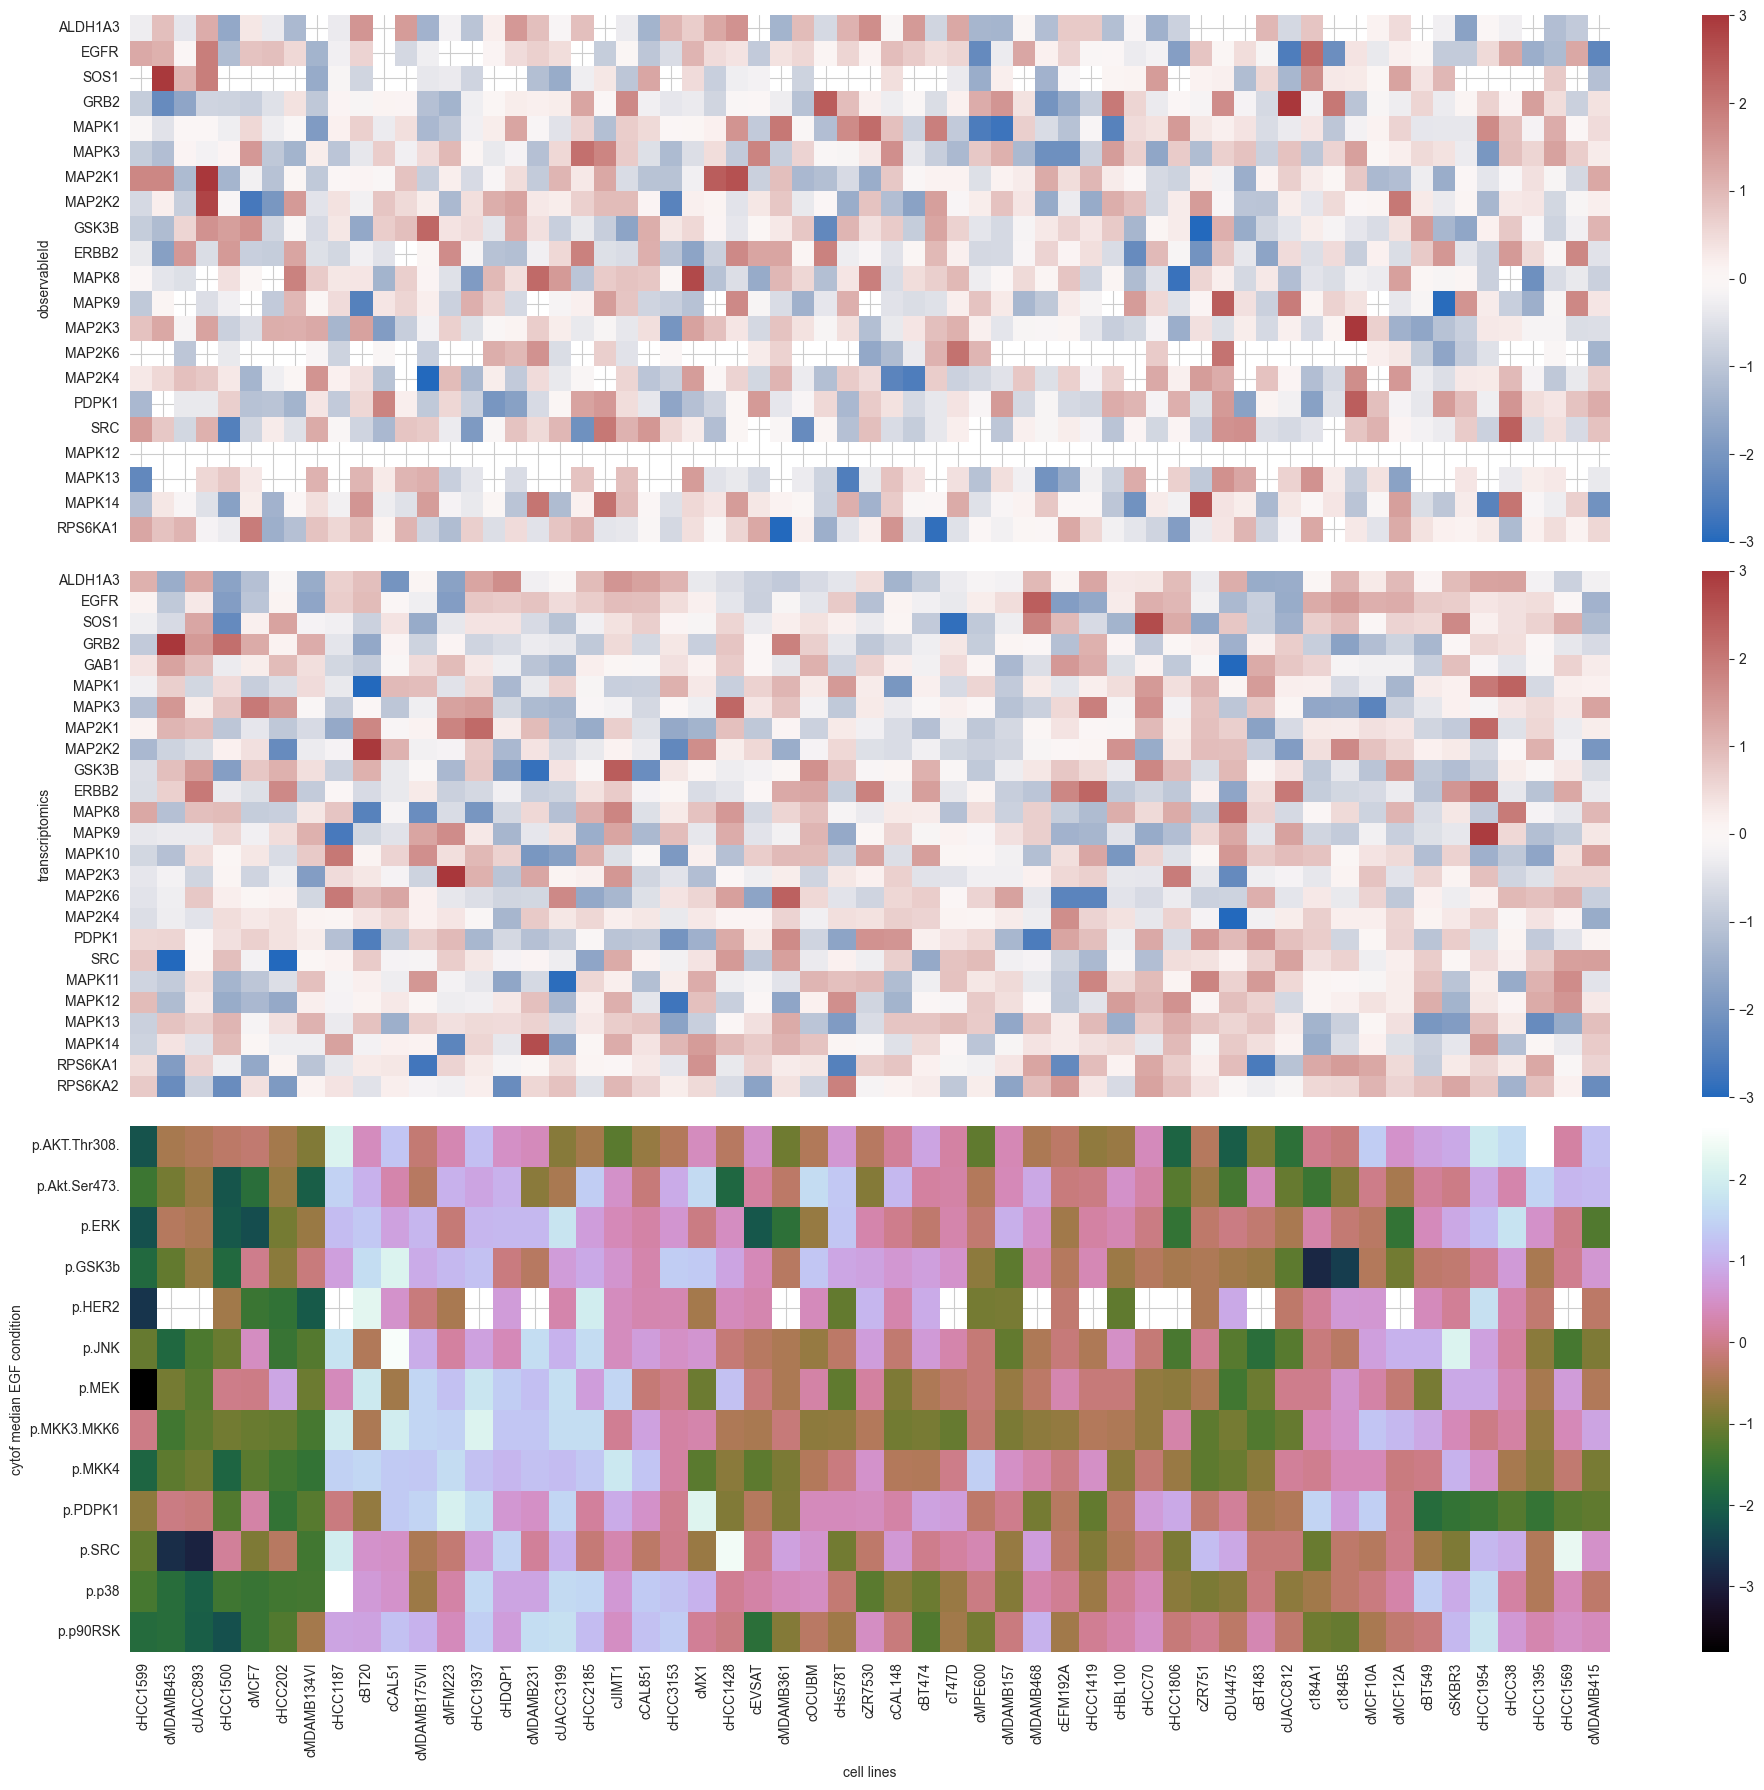

In [376]:
fig, ax = plt.subplots(figsize=(20, 18), nrows=3)

sns.heatmap(
    df_px.loc[[m for m in pmarkers if m in df_px.index]], cmap='vlag', ax=ax[0], vmax=3, vmin=-3
)
ax[0].set_xticklabels([])
ax[2].set_ylabel('proteomics')
ax[0].set_xlabel('')
sns.heatmap(
    df_tx.loc[[m for m in pmarkers if m in df_tx.index],d['ivl']], cmap='vlag', ax=ax[1], vmax=3, vmin=-3
)
ax[1].set_xticklabels([])
ax[1].set_ylabel('transcriptomics')
ax[1].set_xlabel('')
sns.heatmap(
    dfz.loc[d['ivl'],:].T, cmap='cubehelix', ax=ax[2]
)
ax[2].set_ylabel('cytof median EGF condition')
ax[2].set_xlabel('cell lines')
plt.tight_layout()

### MDAMB134VI: KRAS Gly12Arg + MAP2K4 Ser184Leu
### MDAMB453: KRAS Gly13Asp + PIK3CA His1047Arg
### UACC893: PIK3CA mutation His1047Arg
### MCF7: PIK3CA mutation Glu545Lys
### HCC1500: nothing
### HCC202: PIK3CA Glu545Lys

In [373]:
df = pd.read_csv('./data/cytof.csv', index_col=0)
df['treatment'] = df['simulationConditionId'].str.split('__').str[1]

<Axes: xlabel='date', ylabel='preequilibrationConditionId'>

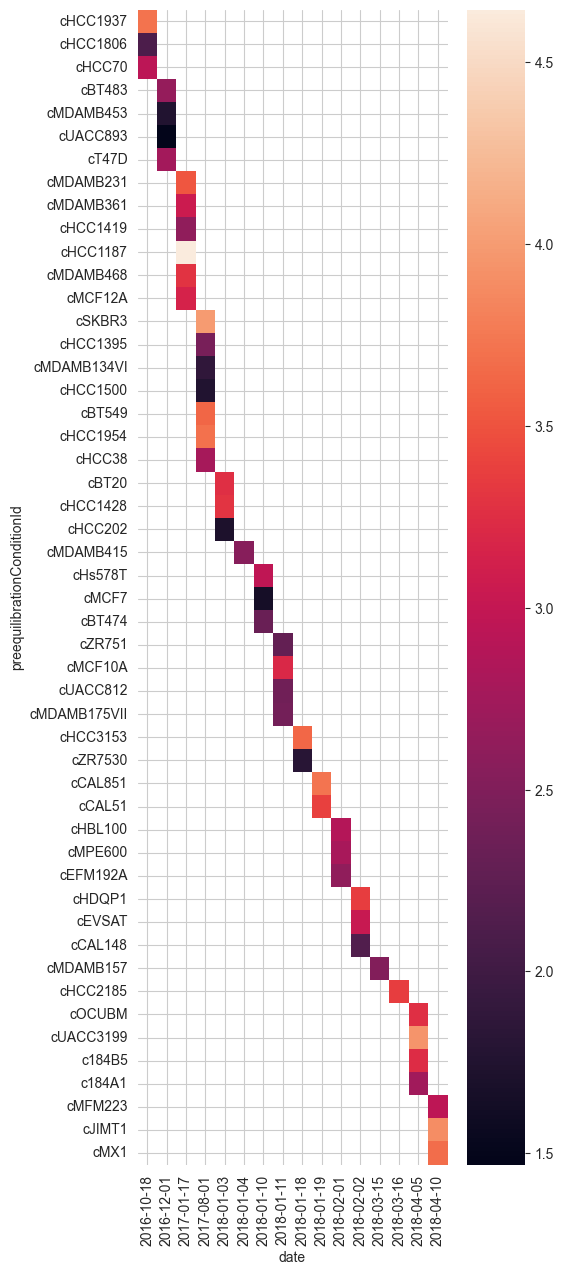

In [374]:
fig, ax = plt.subplots(figsize=(5, 15))
df_date =df[(df.observableId == 'p.p38') & (df.treatment == 'EGF') & (df.time == 13.0)].sort_values('date').pivot_table(
    index='date',
    columns='preequilibrationConditionId',
    values='measurement'
).T
sns.heatmap(df_date.loc[
    df[(df.observableId == 'p.p38') & (df.treatment == 'EGF') & (df.time == 13.0)].sort_values('date')['preequilibrationConditionId'].unique(),:
], ax=ax)


In [375]:
df[(df.observableId == 'p.p38') & (df.treatment == 'EGF') & (df.time == 13.0)].sort_values('min')

,observableId,preequilibrationConditionId,time,date,time_course,measurement,min,noiseParameters,simulationConditionId,measurementType,FEATURE_ID,treatment
82705,p.p38,cMDAMB453,13.0,2016-12-01,A,1.747634,0.203475,1.0,cMDAMB453__EGF,cytof,p.p38,EGF
81821,p.p38,cHCC1937,13.0,2016-10-18,A,3.711339,0.203475,1.0,cHCC1937__EGF,cytof,p.p38,EGF
81561,p.p38,cHCC1419,13.0,2017-01-17,A,2.620964,0.203475,1.0,cHCC1419__EGF,cytof,p.p38,EGF
82310,p.p38,cMCF12A,13.0,2017-01-17,A,3.151169,0.203475,1.0,cMCF12A__EGF,cytof,p.p38,EGF
81470,p.p38,cHCC1187,13.0,2017-01-17,A,4.645137,0.203475,1.0,cHCC1187__EGF,cytof,p.p38,EGF
82751,p.p38,cMDAMB468,13.0,2017-01-17,A,3.290638,0.203475,1.0,cMDAMB468__EGF,cytof,p.p38,EGF
82577,p.p38,cMDAMB231,13.0,2017-01-17,A,3.518996,0.203475,1.0,cMDAMB231__EGF,cytof,p.p38,EGF
82614,p.p38,cMDAMB361,13.0,2017-01-17,A,3.064733,0.203475,1.0,cMDAMB361__EGF,cytof,p.p38,EGF
81783,p.p38,cHCC1806,13.0,2016-10-18,A,2.103788,0.203475,1.0,cHCC1806__EGF,cytof,p.p38,EGF
83011,p.p38,cT47D,13.0,2016-12-01,A,2.753537,0.203475,1.0,cT47D__EGF,cytof,p.p38,EGF
